In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Iris dataset

iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["target"] = iris.target

# Add species name
df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [3]:
# Dataset information

print("Dataset Shape:", df.shape)
print("\nSpecies Count:")
print(df["species"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (150, 6)

Species Count:
species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


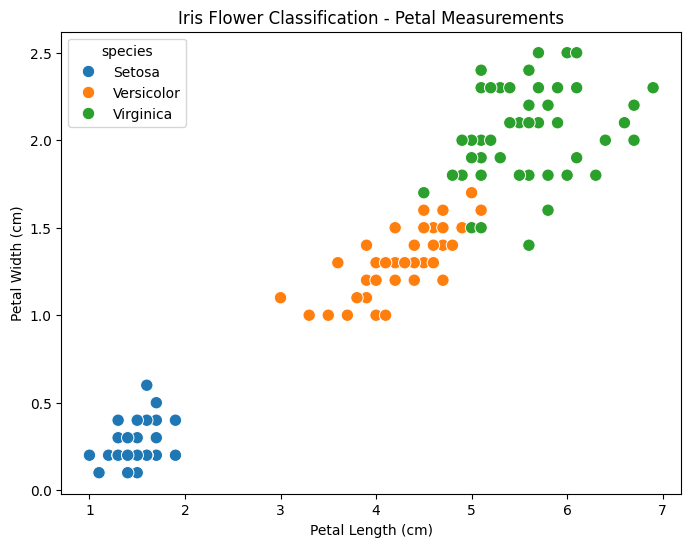

In [4]:
# Visualize Iris dataset

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    s=80
)

plt.title("Iris Flower Classification - Petal Measurements")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.show()

In [5]:
# Select features and target

X = iris.data
y = iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [6]:
# Train Logistic Regression model

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
# Make predictions on test data

y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.9666666666666667
Accuracy Percentage: 96.67 %


In [8]:
# Classification Report

print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



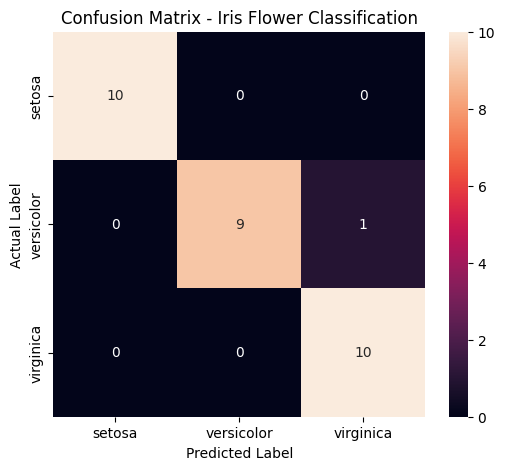

In [9]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - Iris Flower Classification")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [10]:
# Predict a new Iris flower

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

predicted_species = iris.target_names[prediction[0]]

print("Predicted Flower Species:", predicted_species)

Predicted Flower Species: setosa


In [11]:
# Final Project Summary

print("=" * 50)
print("IRIS FLOWER CLASSIFICATION - FINAL RESULT")
print("=" * 50)

print(f"Model Used       : Logistic Regression")
print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")
print(f"Accuracy         : {accuracy * 100:.2f}%")
print(f"New Flower       : {predicted_species}")

print("\nProject Status: Completed Successfully!")

IRIS FLOWER CLASSIFICATION - FINAL RESULT
Model Used       : Logistic Regression
Training Samples : 120
Testing Samples  : 30
Accuracy         : 96.67%
New Flower       : setosa

Project Status: Completed Successfully!
